4 Data Cleaning & Preprocessing
4.1 Drop Unnecessary Columns
Prompt: Which columns should be dropped, and why?

In your Quarto report, explain:
- Which columns are irrelevant or redundant?
- Why are we removing multiple versions of NAICS/SOC codes?
- How will this improve analysis?

4.2 Dropping Unnecessary Columns
We remove redundant NAICS/SOC codes and tracking data to simplify our dataset. Keeping only the latest NAICS_2022_6 and SOC_2021_4 ensures that our analysis reflects current industry and occupational classifications.

4.2.1 Python Implementation
columns_to_drop = [
    "ID", "URL", "ACTIVE_URLS", "DUPLICATES", "LAST_UPDATED_TIMESTAMP",
    "NAICS2", "NAICS3", "NAICS4", "NAICS5", "NAICS6",
    "SOC_2", "SOC_3", "SOC_5"
]
df.drop(columns=columns_to_drop, inplace=True)

4.3 Handle Missing Values
While performing the analysis answer the question: How should missing values be handled?

📄 Quarto Markdown Example

4.4 Handling Missing Values
We use different strategies for missing values:
- Numerical fields (e.g., Salary) are filled with the median.
- Categorical fields (e.g., Industry) are replaced with "Unknown".
- Columns with >50% missing values are dropped.

import missingno as msno

# Visualize missing data
msno.heatmap(df)
plt.title("Missing Values Heatmap")
plt.show()

# Drop columns with >50% missing values
df.dropna(thresh=len(df) * 0.5, axis=1, inplace=True)

# Fill missing values
df["Salary"].fillna(df["Salary"].median(), inplace=True)
df["Industry"].fillna("Unknown", inplace=True)

4.5 Remove Duplicates
📄 Quarto Markdown Example
## Removing Duplicate Job Postings

To ensure each job is counted only once, we remove duplicates based on job title, company, location, and posting date.

df = df.drop_duplicates(subset=["TITLE", "COMPANY", "LOCATION", "POSTED"], keep="first")

5 Exploratory Data Analysis (EDA)
In your Quarto report, explain:
- Why these visualizations were chosen.
- Key insights from each graph.

📄 Quarto Markdown Example

5.1 Job Postings by Industry
Understanding industry demand helps job seekers prioritize skill development.

5.1.1 Job Postings by Industry
fig = px.bar(df["Industry"].value_counts(), title="Job Postings by Industry")
fig.show()

5.1.2 Salary Distribution by Industry
fig = px.box(df, x="Industry", y="Salary", title="Salary Distribution by Industry")
fig.show()

5.1.3 Remote vs. On-Site Jobs
fig = px.pie(df, names="REMOTE_TYPE_NAME", title="Remote vs. On-Site Jobs")
fig.show()

6 Commit & Publish to GitHub
Ensure _quarto.yml is updated to include the “Data Analysis” tab.

quarto render
git add data_analysis.qmd _quarto.yml
git commit -m "Enhanced data cleaning, EDA, and salary outlier handling"
git push origin main

## **Data Cleaning**

In [22]:
from pyspark.sql import SparkSession

# Start a Spark session
spark = SparkSession.builder.appName("JobPostingsAnalysis").getOrCreate()

# Load the CSV file into a Spark DataFrame
df = spark.read.option("header", "true").option("inferSchema", "true").option("multiLine","true").option("escape", "\"").csv("/home/ubuntu/job-market-analysis-project-2026/data/lightcast_job_postings.csv")

# Show schema
df.printSchema()

root
 |-- ID: string (nullable = true)
 |-- LAST_UPDATED_DATE: string (nullable = true)
 |-- LAST_UPDATED_TIMESTAMP: timestamp (nullable = true)
 |-- DUPLICATES: integer (nullable = true)
 |-- POSTED: string (nullable = true)
 |-- EXPIRED: string (nullable = true)
 |-- DURATION: integer (nullable = true)
 |-- SOURCE_TYPES: string (nullable = true)
 |-- SOURCES: string (nullable = true)
 |-- URL: string (nullable = true)
 |-- ACTIVE_URLS: string (nullable = true)
 |-- ACTIVE_SOURCES_INFO: string (nullable = true)
 |-- TITLE_RAW: string (nullable = true)
 |-- BODY: string (nullable = true)
 |-- MODELED_EXPIRED: string (nullable = true)
 |-- MODELED_DURATION: integer (nullable = true)
 |-- COMPANY: integer (nullable = true)
 |-- COMPANY_NAME: string (nullable = true)
 |-- COMPANY_RAW: string (nullable = true)
 |-- COMPANY_IS_STAFFING: boolean (nullable = true)
 |-- EDUCATION_LEVELS: string (nullable = true)
 |-- EDUCATION_LEVELS_NAME: string (nullable = true)
 |-- MIN_EDULEVELS: integer (

In [ ]:
# Only applicable to Shuyu's environment, delete when writing the reports
from pyspark.sql import SparkSession

# Start a Spark session
spark = SparkSession.builder.appName("JobPostingsAnalysis").getOrCreate()

# Load the CSV file into a Spark DataFrame
df = spark.read.option("header", "true").option("inferSchema", "true").option(
    "multiLine", "true").option("escape", "\"").csv("data/lightcast_job_postings.csv")

df.printSchema()
df.show(5)

**Column Selection and Feature Reduction**

The original dataset contains a wide range of variables encompassing job characteristics, classification systems, metadata, and raw textual fields. To ensure analytical clarity and methodological rigor, a systematic feature selection process was undertaken to remove irrelevant, redundant, and excessively granular variables.

First, variables associated with metadata and system-level identifiers were excluded. These include fields such as ID, URL, SOURCES, and timestamp-related columns, which primarily serve operational or tracking purposes rather than contributing meaningful information for analysis. Similarly, raw text fields such as TITLE_RAW and COMPANY_RAW were removed in favor of their cleaned or standardized counterparts, such as TITLE_CLEAN, which provide greater consistency and are more suitable for downstream analysis.

Second, the dataset includes multiple occupational and industry classification systems, including NAICS, SOC, CIP, ONET, and Lightcast’s proprietary taxonomy. While each system provides a structured representation of job and industry characteristics, there is substantial conceptual overlap among them. To reduce redundancy and mitigate the risk of multicollinearity, a single, coherent set of classification variables was selected. Specifically, NAICS2_NAME was retained to represent industry at an aggregate and interpretable level, while LOT_OCCUPATION_NAME and LOT_CAREER_AREA_NAME were used to capture occupational roles and broader career domains. Other classification systems such as SOC, ONET, and CIP were excluded, as they duplicate information already captured by the selected variables without providing additional analytical value.

Furthermore, multiple levels and versions of NAICS codes, including NAICS3 through NAICS6 and NAICS_2022_*, were removed. These variables reflect a hierarchical structure in which more granular levels are nested within broader categories. Including multiple levels simultaneously would introduce redundant information and unnecessarily increase model complexity. Retaining only the 2-digit NAICS classification ensures a balance between interpretability and analytical usefulness while avoiding excessive fragmentation of categories.

Finally, highly granular and versioned taxonomy fields, such as LOT_SPECIALIZED_OCCUPATION_NAME and LOT_V6_* variables, were excluded. These fields tend to generate a large number of distinct categories, which can reduce interpretability, complicate visualization, and negatively impact model performance due to high cardinality.

Overall, this feature reduction process enhances the analytical quality of the dataset by minimizing redundancy, reducing dimensionality, and improving interpretability. By focusing on a carefully selected subset of variables, the analysis becomes more efficient, the resulting models are more stable, and the insights generated are more coherent and actionable.

**Removing Duplicates**

To ensure each job is counted only once, we remove duplicates based on job title, company, location, and posting date.

In [23]:
# select the needed columns 
cols = [
    # job roles
    "TITLE_NAME",
    "TITLE_CLEAN",
    "LOT_OCCUPATION_NAME",
    "LOT_CAREER_AREA_NAME",
    "LOT_SPECIALIZED_OCCUPATION_NAME",
    "LOT_V6_SPECIALIZED_OCCUPATION_NAME",
    "LOT_V6_CAREER_AREA_NAME",

    # skills
    "SKILLS_NAME",
    "SPECIALIZED_SKILLS_NAME",
    "SOFTWARE_SKILLS_NAME",
    "COMMON_SKILLS_NAME",
    "CERTIFICATIONS_NAME",

    # job description
    "BODY",

    # industry
    "NAICS2_NAME",
    "NAICS_2022_2_NAME",
    "LIGHTCAST_SECTORS_NAME",
    

    # experience/education
    "MIN_YEARS_EXPERIENCE",
    "MIN_EDULEVELS_NAME",
    "EDUCATION_LEVELS_NAME", 
    "MIN_EDULEVELS",
    "IS_INTERNSHIP",

    # salary
    "SALARY",
    "SALARY_FROM",
    "SALARY_TO",

    # work setup
    "REMOTE_TYPE_NAME",
    "EMPLOYMENT_TYPE_NAME"
]
    
# remove duplicate job postings using raw columns
df = df.dropDuplicates(["TITLE", "COMPANY", "LOCATION", "POSTED"])

# then explicitly keep only needed columns
df = df.select(*cols)

In [24]:
# print the schema and display the new df
df.printSchema()
df.show(5)

root
 |-- TITLE_NAME: string (nullable = true)
 |-- TITLE_CLEAN: string (nullable = true)
 |-- LOT_OCCUPATION_NAME: string (nullable = true)
 |-- LOT_CAREER_AREA_NAME: string (nullable = true)
 |-- LOT_SPECIALIZED_OCCUPATION_NAME: string (nullable = true)
 |-- LOT_V6_SPECIALIZED_OCCUPATION_NAME: string (nullable = true)
 |-- LOT_V6_CAREER_AREA_NAME: string (nullable = true)
 |-- SKILLS_NAME: string (nullable = true)
 |-- SPECIALIZED_SKILLS_NAME: string (nullable = true)
 |-- SOFTWARE_SKILLS_NAME: string (nullable = true)
 |-- COMMON_SKILLS_NAME: string (nullable = true)
 |-- CERTIFICATIONS_NAME: string (nullable = true)
 |-- BODY: string (nullable = true)
 |-- NAICS2_NAME: string (nullable = true)
 |-- NAICS_2022_2_NAME: string (nullable = true)
 |-- LIGHTCAST_SECTORS_NAME: string (nullable = true)
 |-- MIN_YEARS_EXPERIENCE: integer (nullable = true)
 |-- MIN_EDULEVELS_NAME: string (nullable = true)
 |-- EDUCATION_LEVELS_NAME: string (nullable = true)
 |-- MIN_EDULEVELS: integer (nulla

+----------+-----------+-------------------+--------------------+-------------------------------+----------------------------------+-----------------------+-----------+-----------------------+--------------------+------------------+-------------------+----+-----------+-----------------+----------------------+--------------------+------------------+---------------------+-------------+-------------+------+-----------+---------+----------------+--------------------+
|TITLE_NAME|TITLE_CLEAN|LOT_OCCUPATION_NAME|LOT_CAREER_AREA_NAME|LOT_SPECIALIZED_OCCUPATION_NAME|LOT_V6_SPECIALIZED_OCCUPATION_NAME|LOT_V6_CAREER_AREA_NAME|SKILLS_NAME|SPECIALIZED_SKILLS_NAME|SOFTWARE_SKILLS_NAME|COMMON_SKILLS_NAME|CERTIFICATIONS_NAME|BODY|NAICS2_NAME|NAICS_2022_2_NAME|LIGHTCAST_SECTORS_NAME|MIN_YEARS_EXPERIENCE|MIN_EDULEVELS_NAME|EDUCATION_LEVELS_NAME|MIN_EDULEVELS|IS_INTERNSHIP|SALARY|SALARY_FROM|SALARY_TO|REMOTE_TYPE_NAME|EMPLOYMENT_TYPE_NAME|
+----------+-----------+-------------------+--------------------

In [25]:
# compute the percentage of missing data to assess the approach for data cleaning
from pyspark.sql.functions import col, count, when

total_rows = df.count()

missing_summary = df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).toPandas().T

missing_summary.columns = ["missing_count"]
missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / total_rows * 100
)

missing_summary = missing_summary.sort_values(
    by="missing_percentage",
    ascending=False
)

missing_summary

,missing_count,missing_percentage
LIGHTCAST_SECTORS_NAME,52137,75.344663
SALARY,39960,57.747334
SALARY_TO,38495,55.630221
SALARY_FROM,38495,55.630221
MIN_YEARS_EXPERIENCE,22348,32.295731
TITLE_CLEAN,105,0.151738
LOT_OCCUPATION_NAME,17,0.024567
LOT_CAREER_AREA_NAME,17,0.024567
LOT_SPECIALIZED_OCCUPATION_NAME,17,0.024567
TITLE_NAME,17,0.024567


A small subset of observations (17 rows) contained missing values across nearly all relevant variables. These rows were identified as lacking meaningful information and were removed from the dataset to improve data quality and ensure the integrity of the analysis.


In [26]:
# after inspecting the table above, I noticed there are several 17 missing null values across sveral columns
# my assumption is that these null entries are the same across all columns 
# to verify this assumption I will confirm by checking rows where all these columns aree null
from pyspark.sql.functions import col

cols_to_check = [
    "TITLE_NAME",
    "LOT_CAREER_AREA_NAME",
    "LOT_OCCUPATION_NAME",
    "SPECIALIZED_SKILLS_NAME",
    "SKILLS_NAME",
    "LOT_V6_CAREER_AREA_NAME",
    "LOT_V6_SPECIALIZED_OCCUPATION_NAME",
    "LOT_SPECIALIZED_OCCUPATION_NAME",
    "BODY",
    "SOFTWARE_SKILLS_NAME",
    "COMMON_SKILLS_NAME",
    "NAICS2_NAME",
    "NAICS_2022_2_NAME",
    "CERTIFICATIONS_NAME",
    "MIN_EDULEVELS_NAME",
    "EDUCATION_LEVELS_NAME",
    "IS_INTERNSHIP",
    "MIN_EDULEVELS",
    "REMOTE_TYPE_NAME",
    "EMPLOYMENT_TYPE_NAME"
]

null_rows = df.filter(
    sum([col(c).isNull().cast("int") for c in cols_to_check]) == len(cols_to_check)
)

null_rows.count()

17

In [6]:
# my verification check above returned 17 rows
# now i will visually inspect them to validate
# this will show nulls across all columns
null_rows.show(20, truncate=False)

+----------+-----------+-------------------+--------------------+-------------------------------+----------------------------------+-----------------------+-----------+-----------------------+--------------------+------------------+-------------------+----+-----------+-----------------+----------------------+--------------------+------------------+-------------+-------------+------+-----------+---------+----------------+--------------------+
|TITLE_NAME|TITLE_CLEAN|LOT_OCCUPATION_NAME|LOT_CAREER_AREA_NAME|LOT_SPECIALIZED_OCCUPATION_NAME|LOT_V6_SPECIALIZED_OCCUPATION_NAME|LOT_V6_CAREER_AREA_NAME|SKILLS_NAME|SPECIALIZED_SKILLS_NAME|SOFTWARE_SKILLS_NAME|COMMON_SKILLS_NAME|CERTIFICATIONS_NAME|BODY|NAICS2_NAME|NAICS_2022_2_NAME|LIGHTCAST_SECTORS_NAME|MIN_YEARS_EXPERIENCE|MIN_EDULEVELS_NAME|MIN_EDULEVELS|IS_INTERNSHIP|SALARY|SALARY_FROM|SALARY_TO|REMOTE_TYPE_NAME|EMPLOYMENT_TYPE_NAME|
+----------+-----------+-------------------+--------------------+-------------------------------+-----------

In [27]:
# drop all the null rows
df = df.filter(
    sum([col(c).isNull().cast("int") for c in cols_to_check]) < len(cols_to_check)
)

### **Job Titles & Roles**


In [39]:
# view a smaller subset of selected columns
# specifically the job title related columns
df.select(
    "TITLE_NAME",
    "TITLE_CLEAN",
    "LOT_OCCUPATION_NAME",
    "LOT_CAREER_AREA_NAME",
    "LOT_SPECIALIZED_OCCUPATION_NAME",
    "LOT_V6_SPECIALIZED_OCCUPATION_NAME",
    "LOT_V6_CAREER_AREA_NAME",
).show(20, truncate=False)

+------------+------------------------------------------------------------+-------------------------------------+-------------------------------------------+--------------------------------+----------------------------------+-------------------------------------------+
|TITLE_NAME  |TITLE_CLEAN                                                 |LOT_OCCUPATION_NAME                  |LOT_CAREER_AREA_NAME                       |LOT_SPECIALIZED_OCCUPATION_NAME |LOT_V6_SPECIALIZED_OCCUPATION_NAME|LOT_V6_CAREER_AREA_NAME                    |
+------------+------------------------------------------------------------+-------------------------------------+-------------------------------------------+--------------------------------+----------------------------------+-------------------------------------------+
|Unclassified|want real freedom you need leverage                         |Business Intelligence Analyst        |Information Technology and Computer Science|Oracle Consultant / Analyst     |

In [40]:
# inspect the column
df.select("TITLE_NAME") \
  .distinct() \
  .show(50, truncate=False)

+---------------------------------------+
|TITLE_NAME                             |
+---------------------------------------+
|Project Engineering Managers           |
|Technical Subject Matter Experts       |
|Data Integrity Analysts                |
|Cloud Migration Engineers              |
|Business Systems Specialists           |
|Consulting Members of Technical Staff  |
|Pentaho Developers                     |
|Technology Leads                       |
|Activation Managers                    |
|Application Support Specialists        |
|Statistical Data Analysts              |
|Trust Officers                         |
|Merchandise Analysts                   |
|Bulk Loaders                           |
|Studio Associates                      |
|Registered Dental Assistants           |
|Directors of Elementary                |
|EDI Developers                         |
|Business Unit Managers                 |
|Directors of Philanthropy              |
|ERP Functional Analysts          

In [98]:
# inspect the column
df.select("TITLE_CLEAN") \
  .distinct() \
  .show(50, truncate=False)

+-------------------------------------------------------------------------------------------+
|TITLE_CLEAN                                                                                |
+-------------------------------------------------------------------------------------------+
|entry level business management                                                            |
|oracle scm                                                                                 |
|oracle ebs r service and repair                                                            |
|information security ii data analytics                                                     |
|sap s fico resource                                                                        |
|senior sap sd otc functional                                                               |
|quality data entry a shift am pm                                                           |
|manager oracle scm                                         

In [8]:
# drop these columns after inspecting them
df = df.drop("TITLE_CLEAN", "LOT_CAREER_AREA_NAME","LOT_SPECIALIZED_OCCUPATION_NAME", "LOT_V6_SPECIALIZED_OCCUPATION_NAME", "LOT_V6_CAREER_AREA_NAME")

Reasons for dropping columns:

TITLE_CLEAN : Many entries contained overly verbose, unstructured, or non-standardized job titles that could not be reliably categorized.

LOT_SPECIALIZED_OCCUPATION_NAME: Too granular. 

LOT_CAREER_AREA_NAME: Majority of job postings were concentrated within a single category, “Information Technology and Computer Science,” which reduced its usefulness for segmentation and analysis.

LOT_V6_SPECIALIZED_OCCUPATION_NAME: Same labels as LOT_SPECIALIZED_OCCUPATION_NAME.

LOT_V6_CAREER_AREA_NAME: Same labels as LOT_CAREEER_AREA_NAME and also did not add variability for analysis.

In [104]:
df.select("LOT_OCCUPATION_NAME").distinct().show(truncate=False)

+--------------------------------------------------------------------+
|LOT_OCCUPATION_NAME                                                 |
+--------------------------------------------------------------------+
|Business / Management Analyst                                       |
|Business Intelligence Analyst                                       |
|Market Research Analyst                                             |
|Computer Systems Engineer / Architect                               |
|Data / Data Mining Analyst                                          |
|Clinical Analyst / Clinical Documentation and Improvement Specialist|
+--------------------------------------------------------------------+



In [134]:
df.groupBy("TITLE_NAME") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(100, truncate=False)

+------------------------------------+-----+
|TITLE_NAME                          |count|
+------------------------------------+-----+
|Data Analysts                       |8156 |
|Unclassified                        |2945 |
|Business Intelligence Analysts      |1992 |
|Enterprise Architects               |1891 |
|Oracle Cloud HCM Consultants        |924  |
|Data Modelers                       |652  |
|Data Governance Analysts            |557  |
|Data Analytics Engineers            |508  |
|Data Quality Analysts               |451  |
|Data Management Analysts            |427  |
|Solutions Architects                |424  |
|SAP Consultants                     |411  |
|Data and Reporting Analysts         |405  |
|ERP Business Analysts               |401  |
|SAP EWM Consultants                 |380  |
|Oracle Cloud Financials Consultants |375  |
|Principal Architects                |372  |
|Enterprise Solutions Architects     |350  |
|Data Analytics Interns              |348  |
|Lead Data

In [177]:
# filtering TITLE_NAME column for roles related to topic domain by keyword matching
from pyspark.sql.functions import col, lower

df_filtered = df.filter(
    (lower(col("TITLE_NAME")).contains("data analyst")) |
    (lower(col("TITLE_NAME")).contains("data scientist")) |
    (lower(col("TITLE_NAME")).contains("machine learning")) |
    (lower(col("TITLE_NAME")).contains("ml engineer")) |
    (lower(col("TITLE_NAME")).contains("ai")) |
    (lower(col("TITLE_NAME")).contains("artificial intelligence"))

)

In [178]:
# display the output of filtered values
df_filtered.groupBy("TITLE_NAME") \
    .count() \
    .orderBy("count", ascending=False) \
    .show(100, truncate=False)

+---------------------------------------+-----+
|TITLE_NAME                             |count|
+---------------------------------------+-----+
|Data Analysts                          |8156 |
|Lead Data Analysts                     |342  |
|Master Data Analysts                   |263  |
|Research Data Analysts                 |252  |
|Business Intelligence Data Analysts    |248  |
|IT Data Analysts                       |228  |
|Test Data Analysts                     |169  |
|Enterprise Data Analysts               |166  |
|Health Data Analysts                   |157  |
|Sales Data Analysts                    |155  |
|Technical Data Analysts                |151  |
|Product Data Analysts                  |141  |
|Principal Data Scientists              |136  |
|Data Analyst Managers                  |132  |
|Artificial Intelligence Analysts       |100  |
|Engineering Data Analysts              |91   |
|Customer Data Analysts                 |89   |
|SQL Data Analysts                      

In [9]:
# create a new column called role category to classify jobs in TITLE_NAME into a labeled category 
from pyspark.sql.functions import when, col, lower

title = lower(col("TITLE_NAME"))

df = df.withColumn(
    "ROLE_CATEGORY",
    # Data Scientist (includes ML)
    when(
        title.contains("data scientist") |
        title.contains("machine learning") |
        title.contains("ml engineer") |
        title.contains("ml scientist"),
        "Data Scientist"
    )

    # AI roles
    .when(
        title.contains("artificial intelligence") |
        title.contains(" ai ") |
        title.contains("ai engineer"),
        "AI Engineer/Analyst"
    )

    # Data Analyst + broader analytics roles
    .when(
        title.contains("data analyst") |
        title.contains("data analytics") |
        title.contains("business intelligence") |
        title.contains("bi analyst") |
        title.contains("reporting analyst") |
        title.contains("data and reporting") |
        title.contains("data governance") |
        title.contains("data quality") |
        title.contains("data management") |
        title.contains("data modeler") |
        title.contains("data analytics engineer") |
        title.contains("analytics consultant") |
        title.contains("data analytics intern"),
        "Data Analyst"
    )

    .otherwise("Other")
)

In [16]:
# display role categories created by job listing count 
df.groupBy("ROLE_CATEGORY") \
    .count() \
    .orderBy("count", ascending=False) \
    .show(truncate=False)

+-------------------+-----+
|ROLE_CATEGORY      |count|
+-------------------+-----+
|Other              |47355|
|Data Analyst       |21397|
|Data Scientist     |298  |
|AI Engineer/Analyst|131  |
+-------------------+-----+



In [10]:
# for plotting -keep only relevant roles by removing anything that falls within the Other column
# we will use this df later
df_roles = df.filter(col("ROLE_CATEGORY") != "Other")

In [11]:
# display 
df_roles.groupBy("ROLE_CATEGORY") \
    .count() \
    .orderBy("count", ascending=False) \
    .show(truncate=False)

+-------------------+-----+
|ROLE_CATEGORY      |count|
+-------------------+-----+
|Data Analyst       |21397|
|Data Scientist     |298  |
|AI Engineer/Analyst|131  |
+-------------------+-----+



In [11]:
# visually map the new column ROLE_CATEGORY to TITLE_NAME
# this shows the relation between the two columns and its classified categories
# example: any role with the keywords "data analyst" is categorized as "Data Analyst"
df_roles.groupBy("ROLE_CATEGORY", "TITLE_NAME") \
    .count() \
    .orderBy("count", ascending=False) \
    .show(50, truncate=False)

+-------------------+--------------------------------------------+-----+
|ROLE_CATEGORY      |TITLE_NAME                                  |count|
+-------------------+--------------------------------------------+-----+
|Data Analyst       |Data Analysts                               |8156 |
|Data Analyst       |Business Intelligence Analysts              |1992 |
|Data Analyst       |Data Modelers                               |652  |
|Data Analyst       |Data Governance Analysts                    |557  |
|Data Analyst       |Data Analytics Engineers                    |508  |
|Data Analyst       |Data Quality Analysts                       |451  |
|Data Analyst       |Data Management Analysts                    |427  |
|Data Analyst       |Data and Reporting Analysts                 |405  |
|Data Analyst       |Data Analytics Interns                      |348  |
|Data Analyst       |Lead Data Analysts                          |342  |
|Data Analyst       |Data Analytics Analysts       

### **Skills**

Skill-related variables were processed independently to preserve their distinct meanings, including software, specialized, common skills, and certifications. After filtering the dataset to include only relevant data science and analytics roles, skill values were cleaned and transformed from string-based lists into individual observations. This enabled frequency-based analysis and the identification of the most in-demand skills across roles.

In [17]:
# view a smaller subset of selected columns
# specifically the skills related columns
df.select(
    "SKILLS_NAME",
    "SPECIALIZED_SKILLS_NAME",
    "SOFTWARE_SKILLS_NAME",
    "COMMON_SKILLS_NAME",
    "CERTIFICATIONS_NAME",
).show(20, truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [18]:
# select skills columns
skill_cols = [
    "SOFTWARE_SKILLS_NAME",      # technological skills
    "SPECIALIZED_SKILLS_NAME",   # technical/domain skills
    "COMMON_SKILLS_NAME",        # soft skills
    "CERTIFICATIONS_NAME"        # specialty skills
]

In [13]:
# clean and extract skills
from pyspark.sql.functions import regexp_replace, split, explode, trim, lower, col, lit

# clean the string and remove unwanted characters such as list brackets, quotes, and new lines
def extract_skills(dataframe, skill_col, skill_type):
    cleaned = dataframe.withColumn(
        "SKILL_CLEAN",
        regexp_replace(col(skill_col), r'[\[\]\n"]', "")
    )

# explode so its one row per skill and rename column
    exploded = cleaned.select(
        "ROLE_CATEGORY",
        explode(split(col("SKILL_CLEAN"), ",")).alias("SKILL")
    )

# clean formatting so everything is lower, trim any spaces, and remove empty values
    return exploded.withColumn(
        "SKILL",
        trim(lower(col("SKILL")))
    ).filter(
        (col("SKILL").isNotNull()) & (col("SKILL") != "")
    ).withColumn(
        "SKILL_TYPE",
        lit(skill_type)
    )

In [15]:
# create datasets per skill type
software_df = extract_skills(df_roles, "SOFTWARE_SKILLS_NAME", "software")
specialized_df = extract_skills(df_roles, "SPECIALIZED_SKILLS_NAME", "specialized")
common_df = extract_skills(df_roles, "COMMON_SKILLS_NAME", "common")
certifications_df = extract_skills(df_roles, "CERTIFICATIONS_NAME", "certification")

In [16]:
# window function to extract and aggregate skill datasets to identify the top 15 most frequently occurring skills within each role category
from pyspark.sql.window import Window
from pyspark.sql.functions import col, row_number

def get_top_skills_by_role(df):
    counts = df.groupBy("ROLE_CATEGORY", "SKILL").count()

    window = Window.partitionBy("ROLE_CATEGORY").orderBy(col("count").desc())

    ranked = counts.withColumn(
        "rank",
        row_number().over(window)
    ).filter(col("rank") <= 15)

    return ranked

In [17]:
# analyzs and summarize the data
software_top15 = get_top_skills_by_role(software_df)
specialized_top15 = get_top_skills_by_role(specialized_df)
common_top15 = get_top_skills_by_role(common_df)
certifications_top15 = get_top_skills_by_role(certifications_df)

In [18]:
# show top ranked skills for each skill type

print("SOFTWARE SKILLS")
software_top15.orderBy("ROLE_CATEGORY", "rank").show(100, truncate=False)

print("SPECIALIZED SKILLS")
specialized_top15.orderBy("ROLE_CATEGORY", "rank").show(100, truncate=False)

print("COMMON SKILLS")
common_top15.orderBy("ROLE_CATEGORY", "rank").show(100, truncate=False)

print("CERTIFICATIONS")
certifications_top15.orderBy("ROLE_CATEGORY", "rank").show(100, truncate=False)

SOFTWARE SKILLS


+-------------------+----------------------------------------+-----+----+
|ROLE_CATEGORY      |SKILL                                   |count|rank|
+-------------------+----------------------------------------+-----+----+
|AI Engineer/Analyst|python (programming language)           |63   |1   |
|AI Engineer/Analyst|sql (programming language)              |53   |2   |
|AI Engineer/Analyst|power bi                                |52   |3   |
|AI Engineer/Analyst|chatbot                                 |47   |4   |
|AI Engineer/Analyst|integrated development environments     |46   |5   |
|AI Engineer/Analyst|sas (software)                          |46   |6   |
|AI Engineer/Analyst|microsoft visio                         |46   |7   |
|AI Engineer/Analyst|sql server integration services (ssis)  |44   |8   |
|AI Engineer/Analyst|tableau (business intelligence software)|44   |9   |
|AI Engineer/Analyst|microsoft sql servers                   |44   |10  |
|AI Engineer/Analyst|microsoft azure  

26/04/27 05:42:35 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------------------+----------------------------------------+-----+----+
|ROLE_CATEGORY      |SKILL                                   |count|rank|
+-------------------+----------------------------------------+-----+----+
|AI Engineer/Analyst|data analysis                           |106  |1   |
|AI Engineer/Analyst|artificial intelligence                 |81   |2   |
|AI Engineer/Analyst|machine learning                        |74   |3   |
|AI Engineer/Analyst|computer science                        |65   |4   |
|AI Engineer/Analyst|python (programming language)           |63   |5   |
|AI Engineer/Analyst|data science                            |60   |6   |
|AI Engineer/Analyst|sql (programming language)              |53   |7   |
|AI Engineer/Analyst|statistics                              |53   |8   |
|AI Engineer/Analyst|power bi                                |52   |9   |
|AI Engineer/Analyst|solution design                         |52   |10  |
|AI Engineer/Analyst|project managemen

+-------------------+----------------------------+-----+----+
|ROLE_CATEGORY      |SKILL                       |count|rank|
+-------------------+----------------------------+-----+----+
|AI Engineer/Analyst|problem solving             |57   |1   |
|AI Engineer/Analyst|critical thinking           |50   |2   |
|AI Engineer/Analyst|detail oriented             |50   |3   |
|AI Engineer/Analyst|quality assurance           |48   |4   |
|AI Engineer/Analyst|safety assurance            |46   |5   |
|AI Engineer/Analyst|leadership                  |18   |6   |
|AI Engineer/Analyst|communication               |17   |7   |
|AI Engineer/Analyst|innovation                  |14   |8   |
|AI Engineer/Analyst|interpersonal communications|8    |9   |
|AI Engineer/Analyst|collaboration               |8    |10  |
|AI Engineer/Analyst|management                  |8    |11  |
|AI Engineer/Analyst|presentations               |7    |12  |
|AI Engineer/Analyst|governance                  |7    |13  |
|AI Engi

+-------------------+----------------------------------------------------------------------+-----+----+
|ROLE_CATEGORY      |SKILL                                                                 |count|rank|
+-------------------+----------------------------------------------------------------------+-----+----+
|AI Engineer/Analyst|certified information security manager                                |3    |1   |
|AI Engineer/Analyst|comptia security+                                                     |3    |2   |
|AI Engineer/Analyst|secret clearance                                                      |3    |3   |
|AI Engineer/Analyst|nist cybersecurity framework (csf)                                    |3    |4   |
|AI Engineer/Analyst|certified information systems security professional                   |3    |5   |
|AI Engineer/Analyst|certified information system auditor (cisa)                           |3    |6   |
|AI Engineer/Analyst|servicenow certified system administrator (

In [52]:
import plotly.express as px
import plotly.io as pio

pio.templates.default = "plotly_white"

def plot_skill_type_by_role(df, title):
    pdf = df.toPandas()

    # clean ordering within each role
    pdf = pdf.sort_values(["ROLE_CATEGORY", "count"], ascending=[True, True])

    roles = pdf["ROLE_CATEGORY"].unique()

    for role in roles:
        role_pdf = pdf[pdf["ROLE_CATEGORY"] == role].sort_values("count", ascending=True)

        fig = px.bar(
            role_pdf,
            x="count",
            y="SKILL",
            orientation="h",
            text="count",
            color="count",
            color_continuous_scale="Blues",
            title=f"{title}: {role}",
            height=550,
            width=950
        )

        fig.update_traces(
            textposition="outside",
            marker_line_width=0
        )

        fig.update_layout(
            template="plotly_white",
            plot_bgcolor="white",
            paper_bgcolor="white",
            title=dict(
                x=0.02,
                font=dict(size=22, color="#1f2937")
            ),
            font=dict(size=13, color="#1f2937"),
            xaxis_title="Number of Job Postings",
            yaxis_title="",
            coloraxis_showscale=False,
            margin=dict(l=220, r=80, t=80, b=60)
        )

        fig.update_xaxes(
            showgrid=True,
            gridcolor="#e5e7eb",
            zeroline=False
        )

        fig.update_yaxes(
            showgrid=False
        )

        fig.show()

In [53]:
plot_skill_type_by_role(specialized_top15, "Top 15 Specialized Skills by Role Category")
plot_skill_type_by_role(software_top15, "Top 15 Software Skills by Role Category")
plot_skill_type_by_role(common_top15, "Top 15 Common Skills by Role Category")
plot_skill_type_by_role(certifications_top15, "Top 15 Certifications by Role Category")

### **Job Description**

Missing values in the job description field (BODY) were replaced with empty strings. Since this variable represents unstructured text, imputing numerical values is not appropriate, and removing observations would result in unnecessary data loss. This approach preserves the dataset while allowing for potential text-based analysis without introducing bias.

In [148]:
# replace null values in body with empty string
# this avoids unecessary data loss
df = df.fillna({"BODY": ""})

### **Industry**

In [149]:
# view a smaller subset of selected columns
# specifically the industry related columns
df.select(
    "NAICS2_NAME",
    "NAICS_2022_2_NAME",
    "LIGHTCAST_SECTORS_NAME",
).show(20, truncate=False)

+---------------------+---------------------+-----------------------------------------------------+
|NAICS2_NAME          |NAICS_2022_2_NAME    |LIGHTCAST_SECTORS_NAME                               |
+---------------------+---------------------+-----------------------------------------------------+
|Unclassified Industry|Unclassified Industry|NULL                                                 |
|Unclassified Industry|Unclassified Industry|NULL                                                 |
|Unclassified Industry|Unclassified Industry|NULL                                                 |
|Unclassified Industry|Unclassified Industry|NULL                                                 |
|Unclassified Industry|Unclassified Industry|NULL                                                 |
|Unclassified Industry|Unclassified Industry|NULL                                                 |
|Unclassified Industry|Unclassified Industry|NULL                                                 |


In [150]:
# LIGHTCAST_SECTORS_NAME is being dropped because it has too many missing values
# NAICS_2022_2_NAME is being dropped because it has the same values as NAICS2_NAME
df = df.drop("LIGHTCAST_SECTORS_NAME", "NAICS_2022_2_NAME")

### **Experience & Education**

**Cleaning the MIN_YEARS_EXPERIENCE column**

Missing values in MIN_YEARS_EXPERIENCE were addressed using a hybrid approach. Internship postings were assigned zero experience based on domain knowledge, while remaining missing values were imputed using the median to preserve the distribution and reduce bias.

In [28]:
# internship postings are assingned zero experience
from pyspark.sql.functions import when, col
df = df.withColumn(
    "MIN_YEARS_EXPERIENCE_CLEANED",
    when(
        (col("MIN_YEARS_EXPERIENCE").isNull()) & (col("IS_INTERNSHIP") == True),
        0
    ).otherwise(col("MIN_YEARS_EXPERIENCE"))
)
# drop the helper column AFTER using it
df = df.drop("IS_INTERNSHIP")

# check remaining nulls
print("Remaining nulls:",
      df.filter(col("MIN_YEARS_EXPERIENCE_CLEANED").isNull()).count())

Remaining nulls: 20942


In [29]:
# inspecting whats left after mapping
# this helps us look for nulls, extreme values, and odd distrubtions
df.select("MIN_YEARS_EXPERIENCE_CLEANED").describe().show()

df.groupBy("MIN_YEARS_EXPERIENCE_CLEANED") \
  .count() \
  .orderBy("MIN_YEARS_EXPERIENCE_CLEANED") \
  .show(20)

+-------+----------------------------+
|summary|MIN_YEARS_EXPERIENCE_CLEANED|
+-------+----------------------------+
|  count|                       48239|
|   mean|           5.330624598354029|
| stddev|           3.396512395473762|
|    min|                           0|
|    max|                          15|
+-------+----------------------------+



+----------------------------+-----+
|MIN_YEARS_EXPERIENCE_CLEANED|count|
+----------------------------+-----+
|                        NULL|20942|
|                           0| 2009|
|                           1| 2751|
|                           2| 5983|
|                           3| 6538|
|                           4| 3129|
|                           5|10076|
|                           6| 2614|
|                           7| 3047|
|                           8| 3505|
|                           9|  392|
|                          10| 4897|
|                          11|  189|
|                          12| 2016|
|                          13|   80|
|                          14|  140|
|                          15|  873|
+----------------------------+-----+



The distribution here looks reasonable.
Min = 0 → good (entry-level / internships)
Max = 15 → good (no extreme outliers)
Mean ≈ 5.4 → realistic
Most values between 2–6 years → makes sense for job postings

The minimum years of experience variable was successfully cleaned and validated. Following the imputation of missing values for internship roles, the remaining distribution of experience values was found to be reasonable, with values ranging from 0 to 15 years and a mean of approximately 5.4 years. Remaining missing values, which likely represent unspecified experience requirements, were removed to preserve data integrity and avoid introducing bias through imputation. This resulted in a clean and interpretable feature suitable for regression modeling.

In [30]:
# drop remaining nulls
df = df.dropna(subset=["MIN_YEARS_EXPERIENCE_CLEANED"])

**Cleaning the MIN_EDULEVELS_NAME column and EDUCATION_LEVELS_NAME column**

In [31]:
# Check what education levels exist and spot inconsistencies.
for col_name in ["MIN_EDULEVELS_NAME", "EDUCATION_LEVELS_NAME"]:
    print(f"\n=== {col_name} ===")
    df.groupBy(col_name).count().orderBy("count", ascending=False).show(50, truncate=False)


=== MIN_EDULEVELS_NAME ===


+----------------------------+-----+
|MIN_EDULEVELS_NAME          |count|
+----------------------------+-----+
|Bachelor's degree           |32035|
|No Education Listed         |9824 |
|High school or GED          |2604 |
|Associate degree            |2379 |
|Master's degree             |1348 |
|Ph.D. or professional degree|49   |
+----------------------------+-----+


=== EDUCATION_LEVELS_NAME ===


+------------------------------------------------------------------------------------------------------------------------------------+-----+
|EDUCATION_LEVELS_NAME                                                                                                               |count|
+------------------------------------------------------------------------------------------------------------------------------------+-----+
|[\n  "Bachelor's degree"\n]                                                                                                         |22696|
|[\n  "No Education Listed"\n]                                                                                                       |9824 |
|[\n  "Bachelor's degree",\n  "Master's degree"\n]                                                                                   |8476 |
|[\n  "Associate degree",\n  "Bachelor's degree"\n]                                                                                  |1720 |
|[\n  "Master

In [32]:
# Clean MIN_EDULEVELS_NAME — simple standardization
from pyspark.sql.functions import when, col

# Standardize minimal education level
df = df.withColumn("MIN_EDULEVELS_NAME_CLEAN",
    when(col("MIN_EDULEVELS_NAME") == "Bachelor's degree", "Bachelor")
    .when(col("MIN_EDULEVELS_NAME") == "Master's degree", "Master")
    .when(col("MIN_EDULEVELS_NAME") == "Associate degree", "Associate")
    .when(col("MIN_EDULEVELS_NAME") == "High school or GED", "High School")
    .when(col("MIN_EDULEVELS_NAME") == "Ph.D. or professional degree", "Doctorate")
    .when(col("MIN_EDULEVELS_NAME") == "No Education Listed", "Not Specified")
    .otherwise("Not Specified")
)

In [33]:
from pyspark.sql.functions import regexp_replace, trim

df = df.withColumn("EDUCATION_LEVELS_CLEAN",
    trim(regexp_replace(col("EDUCATION_LEVELS_NAME"), r'[\[\]\"\\n]', ''))
)

In [34]:
# Verify 
df.select("MIN_EDULEVELS_NAME_CLEAN", "EDUCATION_LEVELS_CLEAN").show(20, truncate=False)

+------------------------+------------------------------------------------------------------------------+
|MIN_EDULEVELS_NAME_CLEAN|EDUCATION_LEVELS_CLEAN                                                        |
+------------------------+------------------------------------------------------------------------------+
|Not Specified           |\n  No Educatio Listed\n                                                      |
|Not Specified           |\n  No Educatio Listed\n                                                      |
|Not Specified           |\n  No Educatio Listed\n                                                      |
|Bachelor                |\n  Bachelor's degree\n                                                       |
|Bachelor                |\n  Bachelor's degree\n                                                       |
|Not Specified           |\n  No Educatio Listed\n                                                      |
|High School             |\n  High school or G

### **Salary**

The variables SALARY_FROM and SALARY_TO exhibited a high proportion of missing values, with over 55% of observations lacking complete salary range information. Due to this level of missingness, these variables were excluded from the analysis. Instead, the SALARY variable was retained, as it provides a standardized estimate of compensation and allows for more consistent modeling without substantial data loss.

In [44]:
# drop missing data in salary
# Rows with missing salary values (~57%) were removed to avoid introducing bias through imputation
df = df.dropna(subset=["SALARY"])

# drop salary_from and salary_to
df = df.drop("SALARY_FROM", "SALARY_TO")

### **Work Setup**

**Cleaning EMPLOYMENT_TYPE_NAME column**

The EMPLOYMENT_TYPE_NAME variable was cleaned and consolidated into a new feature, EMPLOYMENT_TYPE_NAME_CLEANED, by standardizing and grouping its distinct values into three clear categories: Part-time, Flexible, and Full-time, improving consistency and interpretability for modeling.

In [49]:
# Inspecting EMPLOYMENT_TYPE_NAME for distinct values
df.select("EMPLOYMENT_TYPE_NAME").distinct().show(100, truncate=False)

+------------------------+
|EMPLOYMENT_TYPE_NAME    |
+------------------------+
|Part-time / full-time   |
|Part-time (â‰¤ 32 hours)|
|Full-time (> 32 hours)  |
+------------------------+



In [51]:
from pyspark.sql.functions import when, col

# rename column categories 
df = df.withColumn(
    "EMPLOYMENT_TYPE_NAME_CLEANED",
    when(col("EMPLOYMENT_TYPE_NAME") == "Full-time (> 32 hours)", "Full-time")
    .when(col("EMPLOYMENT_TYPE_NAME") == "Part-time (â‰¤ 32 hours)", "Part-time")
    .when(col("EMPLOYMENT_TYPE_NAME") == "Part-time / full-time", "Flexible")
    .otherwise("other")
)

# Inspecting EMPLOYMENT_TYPE_NAME for distinct values
df.select("EMPLOYMENT_TYPE_NAME_CLEANED").distinct().show(100, truncate=False)

+----------------------------+
|EMPLOYMENT_TYPE_NAME_CLEANED|
+----------------------------+
|Part-time                   |
|Flexible                    |
|Full-time                   |
+----------------------------+



**Cleaning the REMOTE_TYPE_NAME column**

The REMOTE_TYPE_NAME variable was cleaned and transformed into a new feature, REMOTE_TYPE_NAME_CLEANED, by standardizing and grouping its distinct values into three consistent categories: Remote, Hybrid, and Onsite, improving clarity and making the variable more suitable for modeling. Additionally, any unknown values were assumed to be Hybrid, reflecting common post-COVID-19 pandemic workplace practices where many roles default to a hybrid structure. This improved both the clarity and practical relevance of the variable for modeling.

In [52]:
# Inspecting REMOTE_TYPE_NAME for distinct values
df.select("REMOTE_TYPE_NAME").distinct().show(100, truncate=False)

+----------------+
|REMOTE_TYPE_NAME|
+----------------+
|Remote          |
|[None]          |
|Not Remote      |
|Hybrid Remote   |
+----------------+



In [53]:
from pyspark.sql.functions import when, col, lower, trim

df= df.withColumn(
    "REMOTE_TYPE_NAME_CLEANED",
    trim(lower(col("REMOTE_TYPE_NAME")))
)
df = df.withColumn(
    "REMOTE_TYPE_NAME_CLEANED",
    when(col("REMOTE_TYPE_NAME_CLEANED") == "remote", "remote")
    .when(col("REMOTE_TYPE_NAME_CLEANED") == "hybrid remote", "hybrid")
    .when(col("REMOTE_TYPE_NAME_CLEANED") == "not remote", "onsite")
    .when(col("REMOTE_TYPE_NAME_CLEANED") == "[none]", "hybrid")
    .when(col("REMOTE_TYPE_NAME_CLEANED").isNull(), "hybrid")
    .otherwise("other")
)

#verify categories
df.groupBy("REMOTE_TYPE_NAME_CLEANED").count().show()

+------------------------+-----+
|REMOTE_TYPE_NAME_CLEANED|count|
+------------------------+-----+
|                  onsite|  432|
|                  hybrid|17223|
|                  remote| 5006|
+------------------------+-----+



## **Exploratory Data Analysis**

What are the most in-demand skills for data science, business analytics, and ML roles?
Have job descriptions evolved in 2024 to require AI/ML expertise?
What industries are hiring the most data scientists and why?
What is the career outlook for business analytics professionals?

Figure 1: Top 10 soft skills in Data Analytics, Top 10 certification skills, top 10 softtware skills - grouped by occupation
Figure 2: Top 10 soft skills in Data anlatics grouped by specific roles defined by specific types of roles
Figure 3: filter roles to data scientists, data analyst, etc and count jobs by industry
Figure 4: salary by role category
Figure 5: experience level distribution
skills + Industry heatmap

Education Levels
Work Experience

Top skills	What skills are in demand? 
Skills by role	How roles differ
Industry	Who is hiring
Salary	Career outlook
Experience	Entry vs senior
Remote	Work trends

In [ ]:
# Figure 3: filter roles to data scientists, data analyst, etc and count jobs by industry


In [ ]:
# Figure 4: salary by role category


In [35]:
# Figure 5: experience level distribution
# Bin MIN_YEARS_EXPERIENCE into Entry, Junior, Mid, and Senior categories.
from pyspark.sql.functions import when, col

df = df.withColumn("EXP_CATEGORY",
    when(col("MIN_YEARS_EXPERIENCE").isNull(), "Not Specified")
    .when(col("MIN_YEARS_EXPERIENCE") == 0, "Entry (0 years)")
    .when((col("MIN_YEARS_EXPERIENCE") >= 1) & (col("MIN_YEARS_EXPERIENCE") <= 3), "Junior (1-3 years)")
    .when((col("MIN_YEARS_EXPERIENCE") >= 4) & (col("MIN_YEARS_EXPERIENCE") <= 7), "Mid (4-7 years)")
    .when(col("MIN_YEARS_EXPERIENCE") >= 8, "Senior (8+ years)")
    .otherwise("Other")
)

# Convert to Pandas for plotting
exp_dist = df.groupBy("EXP_CATEGORY").count().orderBy("count", ascending=False).toPandas()

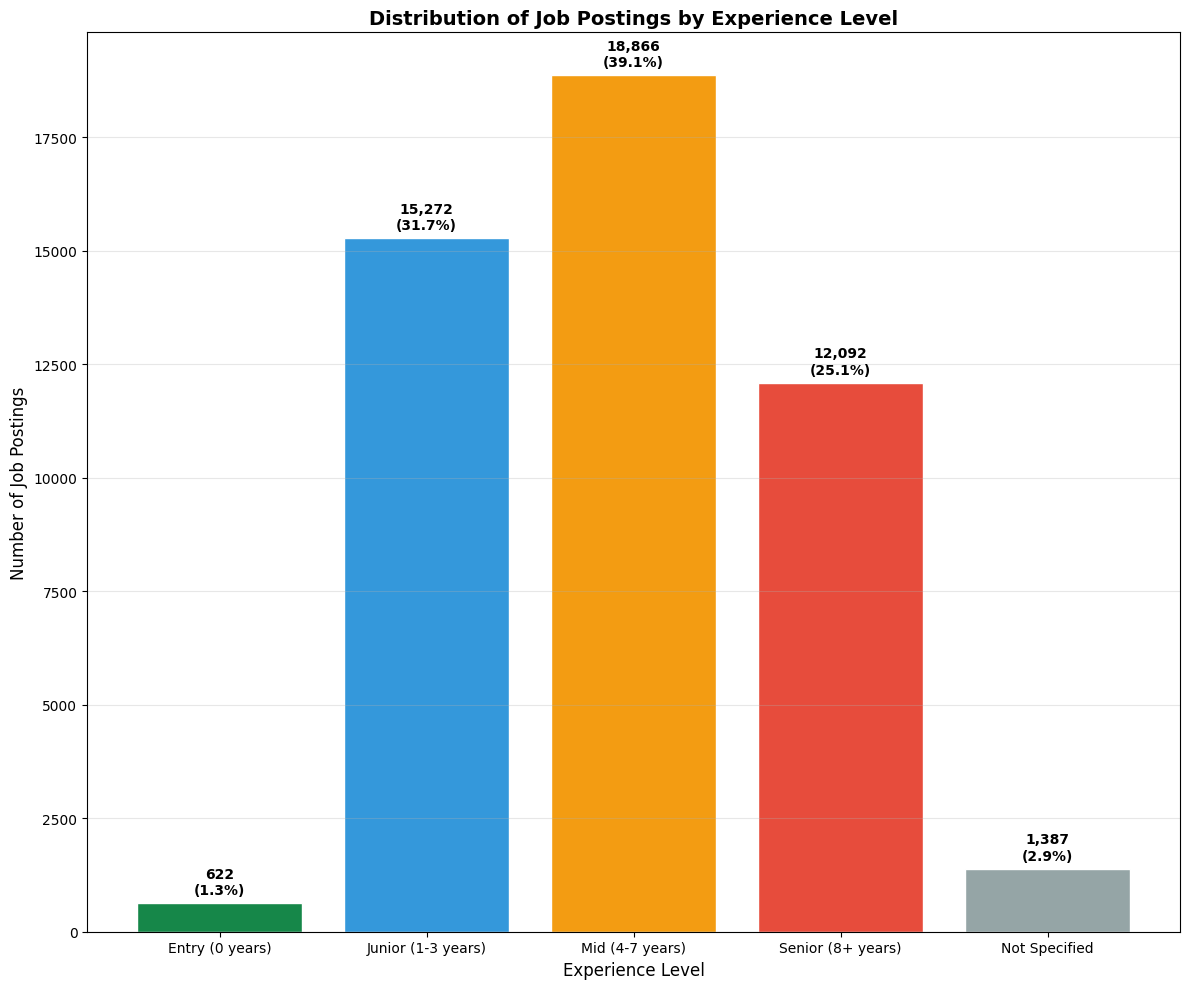

In [36]:
# Bar chart
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define logical order
cat_order = ["Entry (0 years)", "Junior (1-3 years)", "Mid (4-7 years)", "Senior (8+ years)", "Not Specified"]
exp_dist["EXP_CATEGORY"] = pd.Categorical(exp_dist["EXP_CATEGORY"], categories=cat_order, ordered=True)
exp_dist = exp_dist.sort_values("EXP_CATEGORY")

# Plot
plt.figure(figsize=(12, 10))
colors = ["#168749", "#3498db", "#f39c12", "#e74c3c", "#95a5a6"]
bars = plt.bar(exp_dist["EXP_CATEGORY"], exp_dist["count"], color=colors, edgecolor="white")

# Add count labels
for bar, count in zip(bars, exp_dist["count"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f"{count:,}\n({count/exp_dist['count'].sum()*100:.1f}%)",
             ha="center", fontweight="bold")

plt.title("Distribution of Job Postings by Experience Level", fontsize=14, fontweight="bold")
plt.xlabel("Experience Level", fontsize=12)
plt.ylabel("Number of Job Postings", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

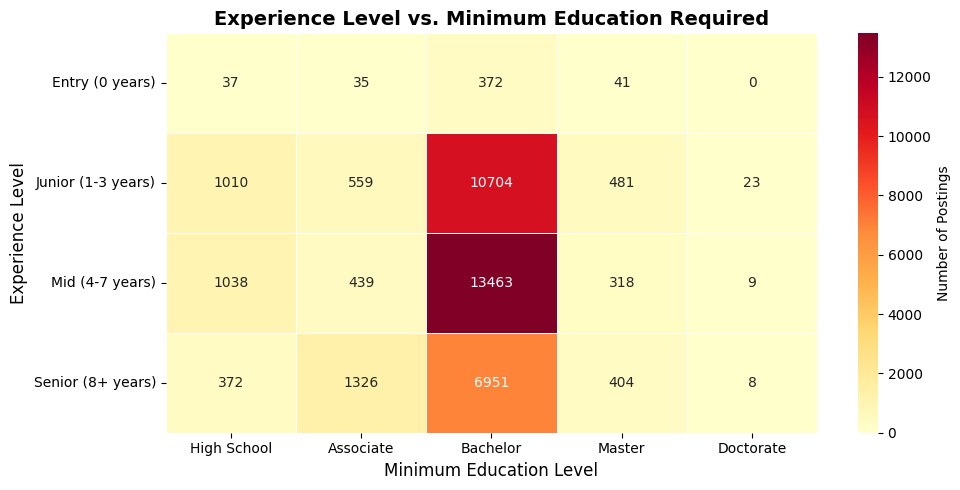

In [37]:
# Heatmap — experience vs. education
# Cross-tab: EXP_CATEGORY vs MIN_EDULEVELS_NAME_CLEAN
cross_df = (
    df.filter(col("EXP_CATEGORY") != "Not Specified")
      .filter(col("MIN_EDULEVELS_NAME_CLEAN") != "Not Specified")
      .groupBy("EXP_CATEGORY", "MIN_EDULEVELS_NAME_CLEAN").count()
      .toPandas()
)

# Pivot to matrix
heatmap_data = cross_df.pivot(index="EXP_CATEGORY", columns="MIN_EDULEVELS_NAME_CLEAN", values="count").fillna(0)

# Reorder rows
edu_col_order = ["High School", "Associate", "Bachelor", "Master", "Doctorate"]
heatmap_data = heatmap_data.reindex(index=cat_order[:-1], columns=edu_col_order).fillna(0)

plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "Number of Postings"})
plt.title("Experience Level vs. Minimum Education Required", fontsize=14, fontweight="bold")
plt.xlabel("Minimum Education Level", fontsize=12)
plt.ylabel("Experience Level", fontsize=12)
plt.tight_layout()
plt.show()

## **Regression, Classification, and Topic Insights**

### **Unsupervised Learning : K Means Clustering using NAICS2**

Skills were included to represent the core requirements of each job, enabling clustering based on differences in technical and domain expertise:

In [31]:
# choose the skills to cluster by
technical_skills = [
    "python",
    "sql",
    "excel",
    "tableau",
    "power bi",
    "r",
    "machine learning",
    "artificial intelligence",
    "data analysis",
    "statistics",
    "math",
    "linear algebra",
    "probability",
    "data visualization",
    "spark",
    "aws",
]

In [32]:
# combine all skill columns into one searchable column
from pyspark.sql.functions import col, lower, concat_ws, coalesce, lit, when, regexp_replace

skill_cols = [
    "SOFTWARE_SKILLS_NAME",
    "SPECIALIZED_SKILLS_NAME",
    "COMMON_SKILLS_NAME",
    "CERTIFICATIONS_NAME"
]

df_skill_features = df.withColumn(
    "ALL_SKILLS_TEXT",
    lower(
        concat_ws(
            " ",
            *[coalesce(col(c), lit("")) for c in skill_cols]
        )
    )
)

In [33]:
# create one binary column per skill
for skill in technical_skills:
    clean_col_name = (
        skill
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )

    df_skill_features = df_skill_features.withColumn(
        f"skill_{clean_col_name}",
        when(col("ALL_SKILLS_TEXT").contains(skill), 1).otherwise(0)
    )

In [34]:
# verify that the text has turned into structured numeric features
# 1 = this job requires the skill
# 0 = this job does not require the skill
df_skill_features.select(
    "TITLE_NAME",
    "ROLE_CATEGORY",
    "skill_python",
    "skill_sql",
    "skill_machine_learning",
    "skill_artificial_intelligence",
    "skill_tableau"
).show(30, truncate=False)

+----------------------------------+-------------+------------+---------+----------------------+-----------------------------+-------------+
|TITLE_NAME                        |ROLE_CATEGORY|skill_python|skill_sql|skill_machine_learning|skill_artificial_intelligence|skill_tableau|
+----------------------------------+-------------+------------+---------+----------------------+-----------------------------+-------------+
|Enterprise Analysts               |Other        |0           |1        |0                     |0                            |0            |
|Oracle Consultants                |Other        |0           |1        |0                     |0                            |0            |
|Data Analysts                     |Data Analyst |0           |0        |0                     |0                            |0            |
|Management Analysts               |Other        |0           |0        |0                     |0                            |0            |
|Unclassified

Build the K Means Clustering Model

In [35]:
# select features
# select numeric + encoded categotical features
features_cols = [
    "SALARY",
    "MIN_YEARS_EXPERIENCE",
    "MODELED_DURATION",
    "MIN_EDULEVELS"
] + [col for col in df_skill_features.columns if col.startswith("skill_")]

In [36]:
# handle any missing values by dropping
df_model = df_skill_features.dropna(subset=[
    "SALARY",
    "MIN_YEARS_EXPERIENCE",
    "MODELED_DURATION",
    "MIN_EDULEVELS_NAME"
])

In [38]:
# asseemble features
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=features_cols,
    outputCol="features"
)

df_model = assembler.transform(df_model)

In [39]:
# scale features
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features"
)

scaler_model = scaler.fit(df_model)
df_model = scaler_model.transform(df_model)

In [40]:
# run k means 
from pyspark.ml.clustering import KMeans

kmeans = KMeans(
    k=4,
    featuresCol="scaled_features",
    seed=42
)

model = kmeans.fit(df_model)
df_clustered = model.transform(df_model)

Clusters

This output displays a sample of job postings along with their assigned cluster, allowing us to observe how individual roles and salaries are distributed across the different KMeans clusters.

In [41]:
df_clustered.select(
    "prediction",
    "SALARY",
    "ROLE_CATEGORY"
).show(20)

+----------+------+-------------+
|prediction|SALARY|ROLE_CATEGORY|
+----------+------+-------------+
|         1|107645| Data Analyst|
|         1|192800|        Other|
|         1|125900|        Other|
|         2|170000|        Other|
|         3|118560|        Other|
|         1|192800|        Other|
|         1| 75026|        Other|
|         1|116500|        Other|
|         1|166500|        Other|
|         3|156038| Data Analyst|
|         1|149695|        Other|
|         2|161200| Data Analyst|
|         0|110000| Data Analyst|
|         1|149695|        Other|
|         2|131091|        Other|
|         1|161200| Data Analyst|
|         1|136400| Data Analyst|
|         2| 54080|        Other|
|         0|161840| Data Analyst|
|         1| 64480|        Other|
+----------+------+-------------+
only showing top 20 rows


In [53]:
import plotly.express as px

plot_df = df_clustered.select(
    "prediction",
    "SALARY",
    "ROLE_CATEGORY"
).toPandas()

plot_df["prediction"] = plot_df["prediction"].astype(str)

fig = px.box(
    plot_df,
    x="prediction",
    y="SALARY",
    color="ROLE_CATEGORY",
    title="Salary Distribution by KMeans Cluster and Role Category",
    labels={
        "prediction": "KMeans Cluster",
        "SALARY": "Salary",
        "ROLE_CATEGORY": "Role Category"
    },
    template="plotly_white"
)

fig.update_layout(
    title_x=0.5,
    font=dict(size=13),
    boxmode="group"
)

fig.show()

In [47]:
import plotly.express as px

pdf = df_clustered.groupBy("prediction") \
    .avg("SALARY") \
    .toPandas()

fig = px.bar(
    pdf,
    x="prediction",
    y="avg(SALARY)",
    color="avg(SALARY)",
    color_continuous_scale="Blues",
    title="Average Salary by Cluster"
)

fig.update_layout(template="plotly_white")
fig.show()

In [48]:
df_clustered.groupBy("prediction", "NAICS_2022_2_NAME") \
    .count() \
    .show()

+----------+--------------------+-----+
|prediction|   NAICS_2022_2_NAME|count|
+----------+--------------------+-----+
|         3|Health Care and S...|   45|
|         1|           Utilities|  103|
|         0|Unclassified Indu...|  395|
|         2|Arts, Entertainme...|    8|
|         1|Educational Services|  207|
|         0|Administrative an...|  558|
|         2|Accommodation and...|   12|
|         0|Health Care and S...|  380|
|         2|Real Estate and R...|   11|
|         0|Finance and Insur...|  787|
|         2|        Construction|   61|
|         3|     Wholesale Trade|   18|
|         0|        Construction|   93|
|         0|        Retail Trade|  124|
|         2|Agriculture, Fore...|    1|
|         0|Management of Com...|    5|
|         2|Public Administra...|   26|
|         1|Professional, Sci...| 3352|
|         3|         Information|  178|
|         2|Health Care and S...|   71|
+----------+--------------------+-----+
only showing top 20 rows


In [52]:
df_clustered.groupBy("prediction") \
    .avg(
        "skill_python",
        "skill_sql",
        "skill_excel",
        "skill_tableau",
        "skill_power_bi",
        "skill_r",
        "skill_machine_learning",
        "skill_artificial_intelligence",
        "skill_data_analysis",
        "skill_statistics",
        "skill_math",
        "skill_linear_algebra",   
        "skill_probability",
        "skill_data_visualization",
        "skill_spark",
        "skill_aws"
    ) \
    .show()

+----------+--------------------+-------------------+-------------------+--------------------+-------------------+------------------+---------------------------+----------------------------------+------------------------+---------------------+--------------------+------------------------+----------------------+-----------------------------+--------------------+--------------------+
|prediction|   avg(skill_python)|     avg(skill_sql)|   avg(skill_excel)|  avg(skill_tableau)|avg(skill_power_bi)|      avg(skill_r)|avg(skill_machine_learning)|avg(skill_artificial_intelligence)|avg(skill_data_analysis)|avg(skill_statistics)|     avg(skill_math)|avg(skill_linear_algbra)|avg(skill_probability)|avg(skill_data_visualization)|    avg(skill_spark)|      avg(skill_aws)|
+----------+--------------------+-------------------+-------------------+--------------------+-------------------+------------------+---------------------------+----------------------------------+------------------------+---------